## Overview 
This notebook analyzes EngageMetrics' approach to flexible work arrangements by investigating whether work modes (REMOTE, HYBRID, ONSITE) influence promotion eligibility. Through progressively independent analysis, for this task, employee_insights_cleanded dataset will be used to test relationships between work arrangements and career advancement opportunities.

To do so, the proposed flow is to form hypotheses, conduct statistical tests, and draw conclusions that could help EngageMetrics optimize their approach to remote work and promotion decisions.

## Learning Outcomes 
- Form and test statistical hypotheses about workplace relationships
- Conduct chi-square tests to analyze categorical relationships
- Interpret statistical test results in business context
- Visualize relationships between variables

## Dataset Information 
The <b>employee_insights_cleaned dataset</b> contains employee records including:
- work_mode (REMOTE, HYBRID, ONSITE)
- promotion_eligible (Y/N)
- department
- work_experience (years)
- satisfaction_score
- projects_completed

## Activities
### Activity 1: Hypothesis Formation and Initial Exploration

<b>Step 1:</b> Form Your Hypothesis. Before examining the data:
1. What factors might influence the relationship between work mode and promotions?
2. Write your hypothesis about this relationship.
3. Document your reasoning.

Discussion prompts:
- How might different work modes affect visibility for promotion?
- Could department or experience levels impact this relationship?
-What other factors should we consider?

<b>Tip:</b> Consider both direct and indirect factors that might influence promotion eligibility.

#### Factors that might influence promotions
- visibility: some modes may make work more visible than others, thus influencing elegibility. Sometimes looking busy affects more than being busy
- other variables like satisfaction_score might have an impact in elegibility. demotivated employees could be less likely to be promoted. satisfacion could also affect projects completed which could in turn affect elegibility for promotions
- experience: there could be a correlation between modes an experience. Experienced workers might prefer a specific mode of work. These workers might be more likely to be promoted than inexperienced ones

<b>Step 2:</b> Import necessary libraries and preview data

In [34]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

<b>Step 3:</b> Adjust paths to import data

In [35]:
BASE_DIR = Path.cwd().resolve().parent
DATA_DIR = BASE_DIR / "data"
employee_insights_path = DATA_DIR / "employee_insights_cleaned.csv"

In [36]:
df = pd.read_csv(employee_insights_path)
df.head()

,employee_id,age,salary,promotion_eligible,last_training_date,department,work_experience,projects_completed,hours_worked_weekly,work_mode,last_promotion_date,satisfaction_score,overtime_hours
0,E0001,53,56910,Y,2022-01-02,It,9,14,44.286826,ONSITE,2020-01-31,9.9,2.1
1,E0002,39,50206,Y,2022-01-09,Hr,12,4,48.524347,ONSITE,2020-02-29,6.8,3.8
2,E0003,32,73419,Y,2022-01-16,Sales,1,9,49.179871,REMOTE,2020-03-31,9.5,9.3
3,E0004,45,100636,Y,2022-01-23,Sales,1,6,50.569759,REMOTE,2020-04-30,4.7,7.2
4,E0005,43,100015,Y,2022-01-30,Hr,15,13,48.605291,HYBRID,2020-05-31,8.3,0.5


<b>Step 4:</b> Initial Data Exploration

In [37]:
print('\nWork mode distribution')
print(df['work_mode'].value_counts())

print('\nPromotions distribution')
print(df['promotion_eligible'].value_counts())


Work mode distribution
work_mode
HYBRID    35
REMOTE    33
ONSITE    32
Name: count, dtype: int64

Promotions distribution
promotion_eligible
N    56
Y    44
Name: count, dtype: int64


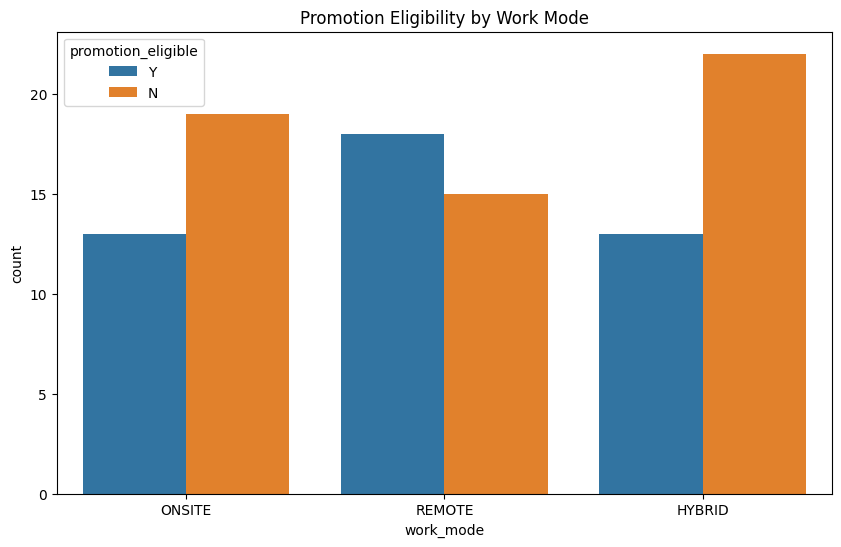

In [38]:
# Basic relationship visualization
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='work_mode', hue='promotion_eligible')
plt.title('Promotion Eligibility by Work Mode')
plt.show()

### Activity 2: Statistical Analysis

<b>Step 1:</b> Create a contingency table examining work_mode and promotion_eligible

Questions to consider:
- What patterns do you notice in the contingency table?
- Do these patterns align with your hypothesis?

In [39]:
contingency_table = pd.crosstab(df['work_mode'], df['promotion_eligible'])
contingency_table_per = pd.crosstab(df['work_mode'], df['promotion_eligible'], normalize='index')

Text(0.5, 1.0, 'Work mode elegibility patterns for promotions')

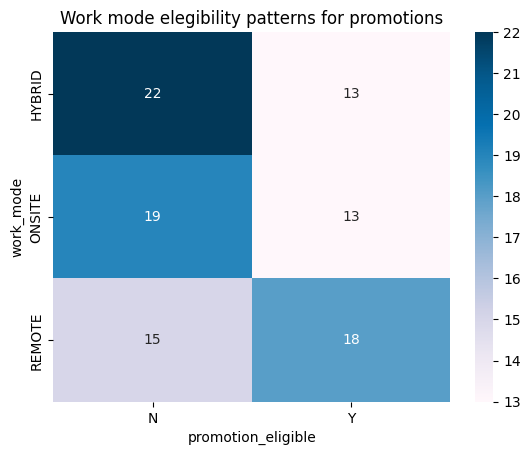

In [40]:
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='PuBu')
plt.title('Work mode elegibility patterns for promotions')

In [41]:
display(contingency_table_per)

promotion_eligible,N,Y
work_mode,,
HYBRID,0.628571,0.371429
ONSITE,0.593750,0.406250
REMOTE,0.454545,0.545455


The pattern is opposite to the expected, there is difference in elegibility in favor of remote workers. 

<b>Step 2:</b> Conduct Perform Chi-Square Test to examine the relationship.

Questions:
- What does the p-value tell us?
- How strong is the relationship?

In [42]:
stat, p, dof, expected = chi2_contingency(contingency_table)
print(f'p-value: {p:.4f}')

p-value: 0.3158


### Activity 3: Advanced Analysis 

<b>Step 1:</b> Investigate Confounding Factors. Analyze how other factors might influence the relationship:
1. Examine promotion rates by department within each work mode
2. Consider work experience as a factor
3. Visualize any patterns you find

#### Analysis by department and mode

In [43]:
dept_work_contingency = pd.crosstab(
    [df['department'], df['work_mode']],
    df['promotion_eligible'], 
) 

dept_work_contingency_per = pd.crosstab(
    [df['department'], df['work_mode']],
    df['promotion_eligible'], 
    normalize='index'
) * 100

<Axes: xlabel='promotion_eligible', ylabel='department-work_mode'>

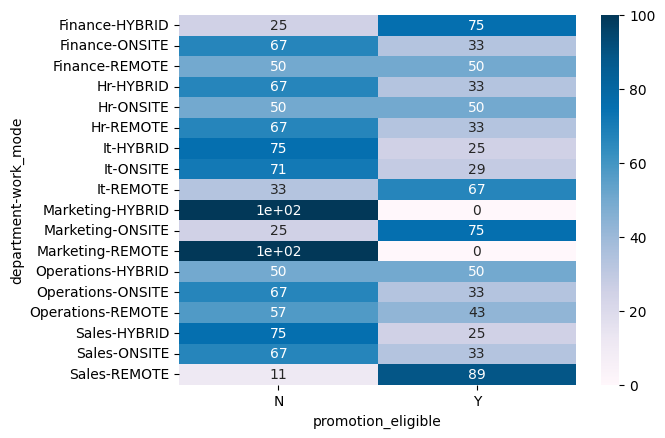

In [44]:
sns.heatmap(dept_work_contingency_per, annot=True, cmap='PuBu')

In [45]:
stat, p, dof, expected = chi2_contingency(dept_work_contingency)
print(f'p-value: {p:.4f}')

p-value: 0.1572


In [46]:
dept_work_promotion = dept_work_contingency_per.copy()
dept_work_promotion['promotion_rate'] = dept_work_promotion['Y']

In [47]:
dept_work_promotion

promotion_eligible             N          Y  promotion_rate
department work_mode                                       
Finance    HYBRID      25.000000  75.000000       75.000000
           ONSITE      66.666667  33.333333       33.333333
           REMOTE      50.000000  50.000000       50.000000
Hr         HYBRID      66.666667  33.333333       33.333333
           ONSITE      50.000000  50.000000       50.000000
           REMOTE      66.666667  33.333333       33.333333
It         HYBRID      75.000000  25.000000       25.000000
           ONSITE      71.428571  28.571429       28.571429
           REMOTE      33.333333  66.666667       66.666667
Marketing  HYBRID     100.000000   0.000000        0.000000
           ONSITE      25.000000  75.000000       75.000000
           REMOTE     100.000000   0.000000        0.000000
Operations HYBRID      50.000000  50.000000       50.000000
           ONSITE      66.666667  33.333333       33.333333
           REMOTE      57.142857  42.857143       42.857143
Sales      HYBRID      75.000000  25.000000       25.000000
           ONSITE      66.666667  33.333333       33.333333
           REMOTE      11.111111  88.888889       88.888889

In [48]:
dept_work_promotion_plot = dept_work_promotion.reset_index()

In [49]:
dept_work_promotion_plot

promotion_eligible,department,work_mode,N,Y,promotion_rate
0,Finance,HYBRID,25.000000,75.000000,75.000000
1,Finance,ONSITE,66.666667,33.333333,33.333333
2,Finance,REMOTE,50.000000,50.000000,50.000000
3,Hr,HYBRID,66.666667,33.333333,33.333333
4,Hr,ONSITE,50.000000,50.000000,50.000000
5,Hr,REMOTE,66.666667,33.333333,33.333333
6,It,HYBRID,75.000000,25.000000,25.000000
7,It,ONSITE,71.428571,28.571429,28.571429
8,It,REMOTE,33.333333,66.666667,66.666667
9,Marketing,HYBRID,100.000000,0.000000,0.000000


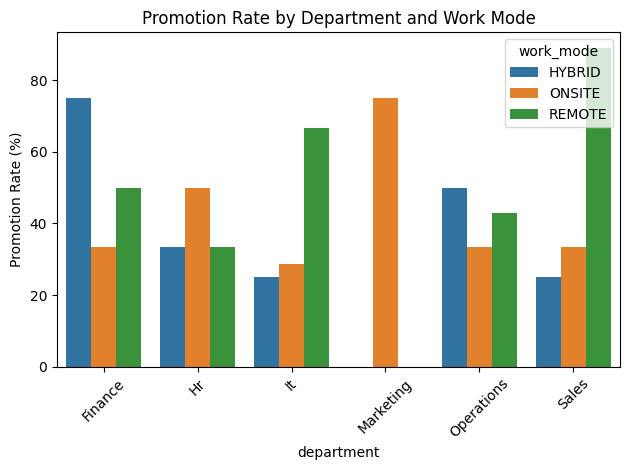

In [50]:
sns.barplot(
    data=dept_work_promotion_plot, 
    x='department', 
    y='promotion_rate', 
    hue='work_mode'
)
plt.title('Promotion Rate by Department and Work Mode')
plt.xticks(rotation=45)
plt.ylabel('Promotion Rate (%)')
plt.tight_layout()
plt.show()

#### Analysis by experience and mode

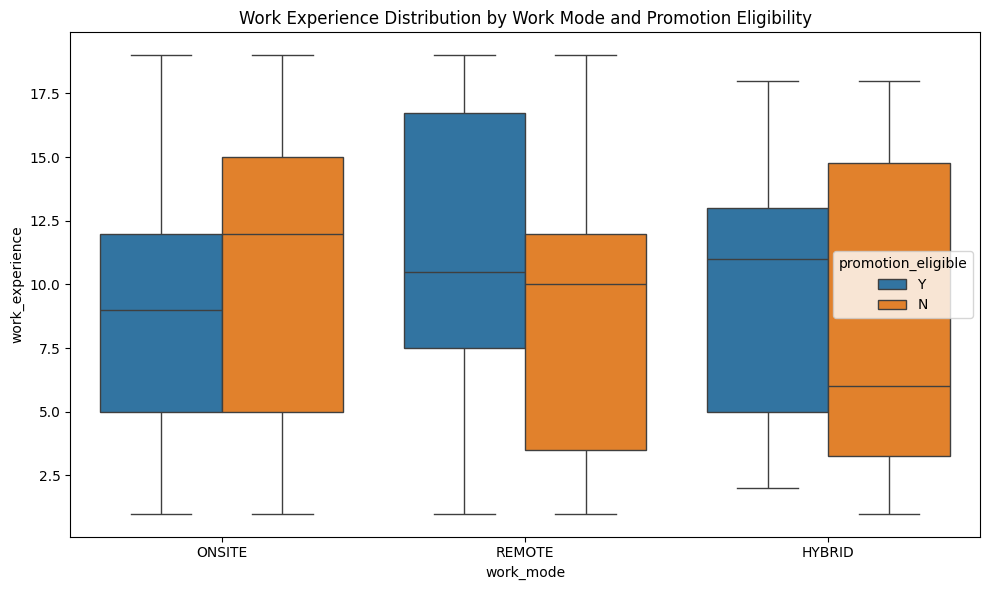

In [51]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='work_mode', y='work_experience', hue='promotion_eligible')
plt.title('Work Experience Distribution by Work Mode and Promotion Eligibility')
plt.tight_layout()
plt.show()

In [54]:
# Experience and promotion eligibility correlation
experience_promotion = pd.crosstab(
    pd.qcut(df['work_experience'], 4), 
    df['promotion_eligible'], 
    normalize='index'
) * 100
print("\nPromotion Rate by Experience Quartile:")
display(experience_promotion)


Promotion Rate by Experience Quartile:


promotion_eligible,N,Y
work_experience,,
"(0.999, 4.0]",67.857143,32.142857
"(4.0, 10.0]",50.000000,50.000000
"(10.0, 15.25]",52.380952,47.619048
"(15.25, 19.0]",52.000000,48.000000
